# Backends: Distribution Functions

This notebook describes how to construct, evaluate, and sample galpy's
distribution functions (DFs) with [JAX](https://docs.jax.dev/) and
[PyTorch](https://pytorch.org/) and how to differentiate them. See the
[quick start](quickstart.ipynb) for an introduction to galpy's backends and
the tutorials on [spherical DFs](../distribution_functions/spherical_dfs.ipynb)
and on [two-](../distribution_functions/disk_df_2d.ipynb) and
[three-dimensional disk DFs](../distribution_functions/disk_df_3d.ipynb) for
the DFs themselves.

On the backends, evaluating a DF and computing its moments are
differentiable for essentially every DF; sampling is differentiable when it
is done by inverse transformation, which is the case for all samplers when
they are given a backend random key; and the construction of a DF is
differentiable when it is itself a numerical computation that runs on the
backends: the spherical DFs that are obtained by inverting a density, the
King model, and the stream models (see the streams notebooks). The
construction of the quasi-isothermal DF is a NumPy computation.

A DF can be set up directly with a parameter that is being differentiated
(a parameter of its potential or density, or of the DF itself), as done
below. **Current requirement:** sampling a
`constantbetadf` or an `osipkovmerrittdf` whose potential has a parameter
that is being differentiated still requires a `galpy.backend.use("jax")` (or
`"torch"`) block around the construction and the sampling, as done below.

In [1]:
%matplotlib inline
import time
import warnings

import jax

jax.config.update("jax_enable_x64", True)
# NumPy's warnings from the end points of some NumPy-path quadratures
warnings.filterwarnings("ignore", category=RuntimeWarning)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy
import torch

import galpy.backend
from galpy.actionAngle import actionAngleStaeckel
from galpy.backend import random as grandom
from galpy.df import (
    constantbetadf,
    dehnendf,
    eddingtondf,
    isotropicHernquistdf,
    kingdf,
    osipkovmerrittdf,
    quasiisothermaldf,
)
from galpy.potential import HernquistPotential, MWPotential2014, NFWPotential

## Sampling with random keys

Every sampler in galpy takes a `key=` argument. Without a key
(`key=None`), it draws from NumPy's global random-number generator, as
before. A JAX or PyTorch key, created with `galpy.backend.random.key`,
selects samplers that draw by inverse transformation of uniform variates
and return JAX arrays or PyTorch tensors:

In [2]:
hdf = isotropicHernquistdf(pot=HernquistPotential(amp=2.0, a=1.3))
numpy.random.seed(1)
sam = hdf.sample(n=10000)
print(type(sam.r()))
key = grandom.key(42, backend="jax")
sam = hdf.sample(n=10000, key=key)
print(type(sam.r()))
tkey = grandom.key(42, backend="torch")
sam_t = hdf.sample(n=10000, key=tkey)
print(type(sam_t.r()))

<class 'numpy.ndarray'>


<class 'jaxlib._jax.ArrayImpl'>
<class 'torch.Tensor'>


The same key gives the same sample:

In [3]:
print(numpy.all(hdf.sample(n=10000, key=key).r() == sam.r()))

True


For spherical DFs, `sample` returns an `Orbit` instance whose coordinates
are backend arrays. Use `galpy.backend.random.split` to obtain independent
keys from a single key.

## Derivatives of samples

For a fixed key, a sample drawn by inverse transformation is a smooth
function of the parameters of the DF and of its potential. Its derivative is
the *pathwise* (or reparameterization) derivative: the derivative of a
statistic of the sample with respect to a parameter is an unbiased estimate
of the derivative of the expected value of that statistic. For a Hernquist
sphere with scale radius $a$, the sampled radii at fixed uniform variates are
proportional to $a$, so $\mathrm{d}\langle r\rangle/\mathrm{d}a = \langle
r\rangle/a$:

In [4]:
def mean_r(a):
    hdf = isotropicHernquistdf(pot=HernquistPotential(amp=2.0, a=a))
    return jnp.mean(hdf.sample(n=10000, key=key).r())


print(jax.jit(jax.grad(mean_r))(1.3), mean_r(1.3) / 1.3)

24.377044988016454 24.377044988016454


The same with PyTorch for a constant-anisotropy DF, whose construction
(the inversion of the density for $f(E)$) is part of the derivative:

In [5]:
a = torch.tensor(1.0, dtype=torch.float64, requires_grad=True)
with galpy.backend.use("torch"):
    cdf = constantbetadf(pot=HernquistPotential(amp=2.0, a=a), beta=-0.2)
    sam = cdf.sample(n=1000, key=grandom.key(7, backend="torch"))
(dr_da,) = torch.autograd.grad(sam.r().sum(), a)
print(dr_da, sam.r().detach().sum() / 1.0)

tensor(17540.3782, dtype=torch.float64) tensor(17540.3782, dtype=torch.float64)


Construction and sampling can be compiled together with `jax.jit`. For an
Osipkov-Merritt DF of a Hernquist sphere, the derivative of the radial
velocity dispersion of the sample with respect to the scale radius agrees
with a finite difference of the same sample (that is, with the same random
numbers):

In [6]:
def sigma_vr(a):
    with galpy.backend.use("jax"):
        omdf = osipkovmerrittdf(pot=HernquistPotential(amp=2.0, a=a), ra=1.5, rmin=0.0)
        sam = omdf.sample(n=10000, key=grandom.key(1, backend="jax"))
    return jnp.std(sam.vr())


sigma_and_grad = jax.jit(jax.value_and_grad(sigma_vr))
start = time.perf_counter()
sig, dsig = sigma_and_grad(1.3)
print(f"First call (compiles): {time.perf_counter() - start:.1f} s")
h = 1e-5
print(dsig, (sigma_and_grad(1.3 + h)[0] - sigma_and_grad(1.3 - h)[0]) / (2.0 * h))

First call (compiles): 12.6 s
-0.07041534509308522 

-0.07041533970908453


Inside `jax.jit`, `rmin` must be given explicitly (`rmin=0` for a
potential that is finite at the center, as here): whether the potential
diverges at the center depends on the values of its parameters, which a
compiled function does not have.

## Evaluating spherical DFs and their moments

Spherical DFs can be evaluated, and their moments computed, at backend
arrays. A DF built from a density that is not the one that generates the
potential (a tracer population) is differentiable with respect to the
parameters of both. For the radial velocity dispersion of a Hernquist tracer
in an NFW halo, with PyTorch:

In [7]:
a_tracer = torch.tensor(0.7, dtype=torch.float64, requires_grad=True)
a_halo = torch.tensor(2.0, dtype=torch.float64, requires_grad=True)
edf = eddingtondf(
    pot=NFWPotential(amp=1.0, a=a_halo),
    denspot=HernquistPotential(amp=0.1, a=a_tracer),
)
sr = edf.sigmar(torch.tensor(1.0, dtype=torch.float64))
sr.backward()
print(sr, a_tracer.grad, a_halo.grad)

tensor(0.1673, dtype=torch.float64, grad_fn=<SqrtBackward0>) tensor(0.0276, dtype=torch.float64) tensor(-0.0593, dtype=torch.float64)


which agree with finite differences in which the DF is rebuilt with NumPy:

In [8]:
def sigmar_numpy(a_tracer, a_halo):
    edf = eddingtondf(
        pot=NFWPotential(amp=1.0, a=a_halo),
        denspot=HernquistPotential(amp=0.1, a=a_tracer),
    )
    return edf.sigmar(1.0)


h = 1e-4
print(
    (sigmar_numpy(0.7 + h, 2.0) - sigmar_numpy(0.7 - h, 2.0)) / (2.0 * h),
    (sigmar_numpy(0.7, 2.0 + h) - sigmar_numpy(0.7, 2.0 - h)) / (2.0 * h),
)

0.027645706167783723 -0.05931705358452888


## The King model and $\mathrm{d}/\mathrm{d}W_0$

The King model is constructed by solving the Poisson equation for its
potential, starting from the dimensionless central potential $W_0$. This
solution is differentiable with respect to $W_0$: in eager mode, galpy
solves the ODE with SciPy and attaches the derivative from the forward
sensitivity equations, while under `jax.jit` it solves the ODE with diffrax.
The derivative of the density profile at fixed mass and tidal radius, $\partial
\ln \rho / \partial W_0$, compared with a finite difference in which the
model is rebuilt:

22.1 s


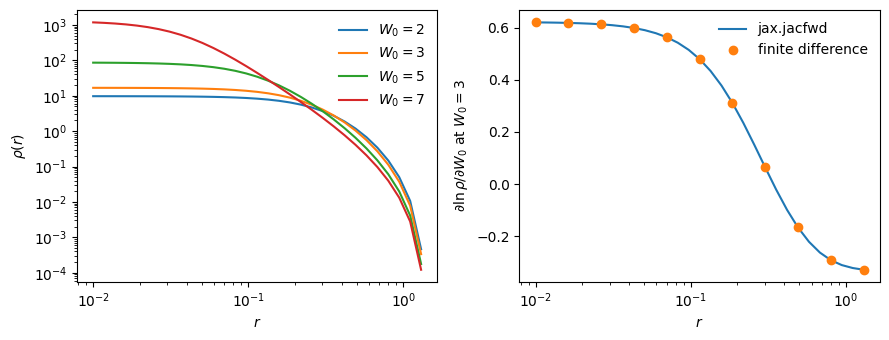

In [9]:
rs = numpy.geomspace(0.01, 1.3, 31)


def ln_dens(W0):
    return jnp.log(kingdf(W0=W0, M=2.3, rt=1.4).dens(rs))


start = time.perf_counter()
dlnrho_dW0 = jax.jacfwd(ln_dens)(3.0)
print(f"{time.perf_counter() - start:.1f} s")
h = 1e-4
fd = (
    numpy.log(kingdf(W0=3.0 + h, M=2.3, rt=1.4).dens(rs))
    - numpy.log(kingdf(W0=3.0 - h, M=2.3, rt=1.4).dens(rs))
) / (2.0 * h)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
for W0 in [2.0, 3.0, 5.0, 7.0]:
    ax1.loglog(rs, kingdf(W0=W0, M=2.3, rt=1.4).dens(rs), label=rf"$W_0={W0:.0f}$")
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$\rho(r)$")
ax1.legend(frameon=False)
ax2.semilogx(rs, dlnrho_dW0, label="jax.jacfwd")
ax2.semilogx(rs[::3], fd[::3], "o", label="finite difference")
ax2.set_xlabel(r"$r$")
ax2.set_ylabel(r"$\partial \ln \rho / \partial W_0$ at $W_0=3$")
ax2.legend(frameon=False)
fig.tight_layout()

The same model can be constructed, evaluated (e.g., `sigmar`), and
sampled inside `jax.jit`, in which case its derivative with respect to $W_0$
goes through the diffrax solution of the Poisson equation; compiling that
takes about a minute on a CPU.

## Disk DFs

### The quasi-isothermal DF

The quasi-isothermal DF is constructed with NumPy, but evaluated, and its
moments computed, on the backends, differentiably with respect to the
phase-space coordinates, the parameters of the potential, and the DF's
scale lengths and velocity dispersions:

In [10]:
aAS = actionAngleStaeckel(pot=MWPotential2014, delta=0.45, c=True)
qdf = quasiisothermaldf(1.0 / 3.0, 0.2, 0.1, 1.0, 1.0, pot=MWPotential2014, aA=aAS)
print(
    qdf(*[torch.tensor([x], dtype=torch.float64) for x in [0.9, 0.1, 1.1, 0.05, 0.02]])
)

tensor([143.7296], dtype=torch.float64)


For the derivative of the radial velocity dispersion at $(R,z) = (0.9,
0.05)$ with respect to the DF's radial velocity-dispersion parameter $\sigma_R$:

In [11]:
sr = torch.tensor(0.2, dtype=torch.float64, requires_grad=True)
qdf_t = quasiisothermaldf(1.0 / 3.0, sr, 0.1, 1.0, 1.0, pot=MWPotential2014, aA=aAS)
sigmaR2 = qdf_t.sigmaR2(
    torch.tensor(0.9, dtype=torch.float64), torch.tensor(0.05, dtype=torch.float64)
)
sigmaR2.backward()
print(sigmaR2, sr.grad)

tensor(0.0515, dtype=torch.float64, grad_fn=<DivBackward0>) tensor(0.5242, dtype=torch.float64)


which agrees with a finite difference in which the DF is rebuilt with NumPy:

In [12]:
h = 1e-5
print(
    (
        quasiisothermaldf(
            1.0 / 3.0, 0.2 + h, 0.1, 1.0, 1.0, pot=MWPotential2014, aA=aAS
        ).sigmaR2(0.9, 0.05)
        - quasiisothermaldf(
            1.0 / 3.0, 0.2 - h, 0.1, 1.0, 1.0, pot=MWPotential2014, aA=aAS
        ).sigmaR2(0.9, 0.05)
    )
    / (2.0 * h)
)

0.5242087907166709


The velocity sampler at a given position, `sampleV`, draws by inverse
transformation on a three-dimensional velocity grid when given a backend
key, and returns an array of that backend:

In [13]:
vs = qdf.sampleV(0.9, 0.05, n=10**4, key=grandom.key(0, backend="jax"))
print(type(vs), vs.shape)
print(jnp.std(vs[:, 0]), jnp.sqrt(qdf.sigmaR2(0.9, 0.05)))

<class 'jaxlib._jax.ArrayImpl'> (10000, 3)


0.22838090407210573 0.22701107926962688


The interpolated sampler that samples many positions at once is a
rejection sampler that runs on the backends but is not differentiable.

### Two-dimensional disk DFs

The moments of the two-dimensional disk DFs (`dehnendf` and `shudf`) are
computed with Gauss-Legendre quadrature on the backends, at a single radius
or at an array of radii, and are differentiable with respect to the radius
and to the parameters of the surface-density and velocity-dispersion
profiles. For the derivative of $\sigma_R^2(R)$ with respect to the scale
length of the surface density, at a set of radii, compared with a finite
difference in which the DF is rebuilt with NumPy:

In [14]:
Rs = numpy.linspace(0.5, 2.0, 11)


def sigmaR2_of_hr(hr):
    return dehnendf(beta=0.0, profileParams=(hr, 1.0, 0.2)).sigmaR2(Rs)


dsigmaR2_dhr = jax.jacfwd(sigmaR2_of_hr)(1.0 / 3.0)
h = 1e-5
fd = (
    dehnendf(beta=0.0, profileParams=(1.0 / 3.0 + h, 1.0, 0.2)).sigmaR2(Rs)
    - dehnendf(beta=0.0, profileParams=(1.0 / 3.0 - h, 1.0, 0.2)).sigmaR2(Rs)
) / (2.0 * h)
print(dsigmaR2_dhr)
print("Largest difference:", numpy.max(numpy.fabs(dsigmaR2_dhr - fd)))

[ 0.01921219  0.01109631  0.00583666  0.00253012  0.00057686 -0.0004554
 -0.00089068 -0.00097099 -0.0008688  -0.00069675 -0.00051953]
Largest difference: 1.5419488602619325e-11
